# **<center>11_eval_exp04_training_set_size_ablation</center>**

### Table of Contents

1. **Notebook Overview**  
   - Objective: impact of training data volume on DL performance  
   - Incremental training strategy (25%, 50%, 75% and 100% of the dataset)  
   - Clinical and methodological motivation  

2. **Environment Setup**  
   - Import of required libraries and utility functions  
   - Basic configuration for plotting and reproducibility  

3. **Loading Images, Labels and Metadata**  
   - 3.1. Load test images  
   - 3.2. Load metadata  
   - Label extraction and consistency checks  

4. **Load Trained Models**  
   - Best CNN models trained with 25%, 50%, 75% and 100% of the training data  
   - Model architecture consistency across experiments  

5. **Models Evaluation: Incremental training-set sizes (25/50/75/100%)**  
   - 5.1. Evaluation of each model on the test set  
       - Probabilistic inference and optimal threshold selection (Youden index)  
       - Confusion matrices and global performance metrics  
         (sensitivity, specificity, PPV, NPV, F1-score, accuracy)  
       - ROC curve analysis and AUC with analytical confidence intervals  
       - Saving of quantitative results and ROC figures to disk
   - 5.2. Statistical Comparison Between Models  
     - Paired comparison of ROC AUC using the DeLong test  
     - Paired comparison of classification errors using McNemar’s test  

7. **Models Explainability**  
   - Grad-CAM-based visual explanation of CNN predictions  
   - Heatmap generation for each incremental model  
   - Qualitative comparison across training-set sizes  

8. **Summary and Conclusions**  
   - Impact of training data volume on performance and robustness  
   - Quantitative and qualitative synthesis of results  
   - Implications for dataset design in clinical DL applications  


### **1. Notebook Overview**

In Experiment 4 we investigate the impact of training dataset size on the diagnostic performance of deep learning (DL) models for the detection of rotator cuff tendon calcifications in shoulder radiographs. Starting from the same CNN architecture and training configuration, four models are trained using incremental proportions of the available training data (25%, 50%, 75% and 100%). The objective is to quantify how increasing the amount of training data affects classification accuracy, robustness, and discriminative capacity.

All models are trained using subsets extracted from the same institutional dataset, ensuring consistent acquisition protocols, labeling criteria and preprocessing steps across experiments. By progressively increasing the number of images available during training while keeping the test set fixed, this experiment isolates the effect of data volume from other confounding factors such as architecture changes or hyperparameter tuning. Each model is evaluated on the same external test set, allowing a direct and fair comparison of performance across training regimes.

Understanding how model performance scales with data availability is critical in medical imaging, where large, well-annotated datasets are often difficult to obtain. This experiment aims to identify whether robust diagnostic performance can be achieved with partial datasets, and at which point additional data yield diminishing returns. The results provide practical guidance for dataset curation strategies and help define realistic data requirements for developing clinically reliable DL systems under real-world constraints.

### **2. Environment Setup: Import required libraries**

In [4]:
# TensorFlow & Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import load_model

# NumPy & Pandas
import numpy as np
import pandas as pd

# Scikit-learn
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

# Visualization
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from IPython.display import Image, display
import math

# System utilities & processing
import os
import cv2
from tqdm import tqdm
from datetime import datetime
from scipy import stats
import seaborn as sns

from scipy.stats import norm

### **3. Load images and metadata**

#### **3.1. Load images**

In [6]:
# Base directory containing the subsets (UNet-cropped version)
subsets_path = "HRJC_test_final/Subsets_unet_crop'"

# Retrieve the list of all subset folders
subset_folders = [
    folder for folder in os.listdir(subsets_path)
    if os.path.isdir(os.path.join(subsets_path, folder))
]

# Dictionary to store image paths per subset
external_subsets = {}

for folder in subset_folders:
    folder_path = os.path.join(subsets_path, folder)

    image_paths = [
        os.path.join(folder_path, fname)
        for fname in os.listdir(folder_path)
        if fname.endswith(".npy")
    ]

    external_subsets[folder] = image_paths
    print(f"Images in {folder}: {len(image_paths)}")

# Display total number of subsets
print(f"\nTotal subsets: {len(external_subsets)}")


Images in MININT-VSAMOTD_test: 56
Images in RADIOLOGIA-HP_test: 172
Images in CZC1198HNN_test: 252

Total subsets: 3


In [7]:
# Load images

def load_images(images_path):
    X_list = []
    shapes_detected = set()

    for image_path in tqdm(images_path, desc='📥 Cargando imágenes'):
        try:
            X_ = np.load(image_path)
            shapes_detected.add(X_.shape)
            X_list.append(X_)
        except Exception as e:
            print(f' Error al cargar {image_path}: {e}')

    if len(shapes_detected) > 1:
        print(f' Se detectaron múltiples shapes: {shapes_detected}')
    else:
        print(f' Todas las imágenes tienen shape: {list(shapes_detected)[0]}')

    try:
        X = np.stack(X_list)  # más seguro que np.array en este contexto
    except Exception as e:
        print(f' Error al convertir lista a array: {e}')
        X = X_list  # fallback: devuelve la lista sin convertir a array

    return X


In [8]:
# === Load external test images ===
X_external_dict = {}

for subset_name, image_paths in external_subsets.items():
    print(f"\nLoading images from external subset: {subset_name}")

    X_external_dict[subset_name] = load_images(image_paths)

    print(
        f"Loaded {X_external_dict[subset_name].shape[0]} images "
        f"from subset {subset_name}"
    )

# === Concatenate all external images into a single array ===
X_all = np.concatenate(list(X_external_dict.values()), axis=0)

print(f"\nAll external images concatenated. Final shape: {X_all.shape}")



Loading images from external subset: MININT-VSAMOTD_test


📥 Cargando imágenes: 100%|████████████████████| 56/56 [00:00<00:00, 462.52it/s]


 Todas las imágenes tienen shape: (300, 300, 3)
Loaded 56 images from subset MININT-VSAMOTD_test

Loading images from external subset: RADIOLOGIA-HP_test


📥 Cargando imágenes: 100%|██████████████████| 172/172 [00:00<00:00, 562.60it/s]


 Todas las imágenes tienen shape: (300, 300, 3)
Loaded 172 images from subset RADIOLOGIA-HP_test

Loading images from external subset: CZC1198HNN_test


📥 Cargando imágenes: 100%|██████████████████| 252/252 [00:00<00:00, 906.02it/s]


 Todas las imágenes tienen shape: (300, 300, 3)
Loaded 252 images from subset CZC1198HNN_test

All external images concatenated. Final shape: (480, 300, 300, 3)


#### **3.2. Load metadata**

In [9]:
# === Load metadata DataFrames for external subsets ===
df_external_dict = {}

# Load the CSV file associated with each subset
for subset_name in external_subsets.keys():
    csv_path = os.path.join(subsets_path, f"{subset_name}.csv")

    df = pd.read_csv(csv_path)
    df_external_dict[subset_name] = df

    print(f"Rows in {subset_name}: {df.shape[0]}")

# === Concatenate all metadata DataFrames into a single DataFrame ===
df_all = pd.concat(df_external_dict.values(), axis=0).reset_index(drop=True)

print(f"Combined DataFrame shape: {df_all.shape}")


Rows in MININT-VSAMOTD_test: 56
Rows in RADIOLOGIA-HP_test: 172
Rows in CZC1198HNN_test: 252
Combined DataFrame shape: (480, 16)


In [10]:
# Extract labels for a list of image paths based on metadata stored in a DataFrame

def extract_labels(df, images_path):
    # Crear diccionario: rx_cod → label
    label_dict = dict(zip(df['rx_cod'], df['label_CalTend']))
    
    # Extraer etiquetas basadas en el nombre del archivo (sin extensión)
    y = np.array([
        label_dict[os.path.splitext(os.path.basename(path))[0]]
        for path in images_path
    ])
    
    return y
    

In [11]:
# Extract labels for external subsets
y_external_dict = {}

for subset_name in external_subsets.keys():
    print(f"\nExtracting labels for subset: {subset_name}")

    image_paths = external_subsets[subset_name]
    df = pd.read_csv(os.path.join(subsets_path, f"{subset_name}.csv"))

    y = extract_labels(df, image_paths)
    y_external_dict[subset_name] = y

    print(f"Extracted labels: {len(y)}")



Extracting labels for subset: MININT-VSAMOTD_test
Extracted labels: 56

Extracting labels for subset: RADIOLOGIA-HP_test
Extracted labels: 172

Extracting labels for subset: CZC1198HNN_test
Extracted labels: 252


In [12]:
# Concatenate external image arrays
X_all = np.concatenate(
    [X_external_dict[name] for name in external_subsets.keys()],
    axis=0
)
print(f"Total number of images: {X_all.shape}")


# === Concatenate external label arrays ===
y_all = np.concatenate(
    [y_external_dict[name] for name in external_subsets.keys()],
    axis=0
)
print(f"Total number of labels: {y_all.shape}")


# Concatenate external metadata DataFrames
df_all = (
    pd.concat(
        [df_external_dict[name] for name in external_subsets.keys()],
        axis=0
    )
    .reset_index(drop=True)
)
print(f"Total number of rows in df_all: {df_all.shape}")


# Final consistency check
assert (
    X_all.shape[0] == y_all.shape[0] == df_all.shape[0]
), "Mismatch between images, labels, and metadata"


Total number of images: (480, 300, 300, 3)
Total number of labels: (480,)
Total number of rows in df_all: (480, 16)


### **4. Load Models**

In [13]:
# === Paths to the best CNN models obtained in Experiment 4 ===
model_path_25   = 'Models/model_25'
model_path_50   = 'Models/model_50'
model_path_75   = 'Models/model_75'
model_path_100  = 'Models/model_100'

# === Load trained models ===

model_25  = load_model(model_path_25)
model_50  = load_model(model_path_50)
model_75  = load_model(model_path_75)
model_100 = load_model(model_path_100)

# === Display model summaries ===

model_25.summary()
model_50.summary()
model_75.summary()
model_100.summary()

2026-02-05 16:19:12.401392: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-02-05 16:19:12.466620: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-02-05 16:19:12.469924: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg19 (Functional)          (None, 9, 9, 512)         20024384  
                                                                 
 global_max_pooling2d (Glob  (None, 512)               0         
 alMaxPooling2D)                                                 
                                                                 
 dense (Dense)               (None, 1)                 513       
                                                                 
Total params: 20024897 (76.39 MB)
Trainable params: 20024897 (76.39 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg19 (Functional)          (None, 9, 9, 512)         20024

### **5. Models Evaluation: Incremental training-set sizes (25/50/75/100%)**

#### **5.1. Models evaluation on the test subset**


=== Evaluation: model_25 ===


2026-02-05 16:19:33.238880: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600


15/15 [==============================] - 11s 244ms/step
Confusion matrix:
[[185 55]
 [64 176]]

cut_off_threshold_point: 0.7026000022888184
Sensitivity: 0.7333
Specificity: 0.7708
PPV: 0.7619
NPV: 0.743
F1 score: 0.7473
Accuracy: 0.7521
ROC AUC: 0.8
CI 90%: [0.7668 – 0.8333]
CI 95%: [0.7604 – 0.8396]
CI 99%: [0.748 – 0.8521]

=== Evaluation: model_50 ===
15/15 [==============================] - 4s 262ms/step
Confusion matrix:
[[208 32]
 [56 184]]

cut_off_threshold_point: 0.6272000074386597
Sensitivity: 0.7667
Specificity: 0.8667
PPV: 0.8519
NPV: 0.7879
F1 score: 0.807
Accuracy: 0.8167
ROC AUC: 0.8906
CI 90%: [0.8655 – 0.9156]
CI 95%: [0.8607 – 0.9204]
CI 99%: [0.8513 – 0.9298]

=== Evaluation: model_75 ===
15/15 [==============================] - 4s 262ms/step
Confusion matrix:
[[228 12]
 [47 193]]

cut_off_threshold_point: 0.8094000220298767
Sensitivity: 0.8042
Specificity: 0.95
PPV: 0.9415
NPV: 0.8291
F1 score: 0.8674
Accuracy: 0.8771
ROC AUC: 0.9243
CI 90%: [0.9035 – 0.9452]
CI 95%

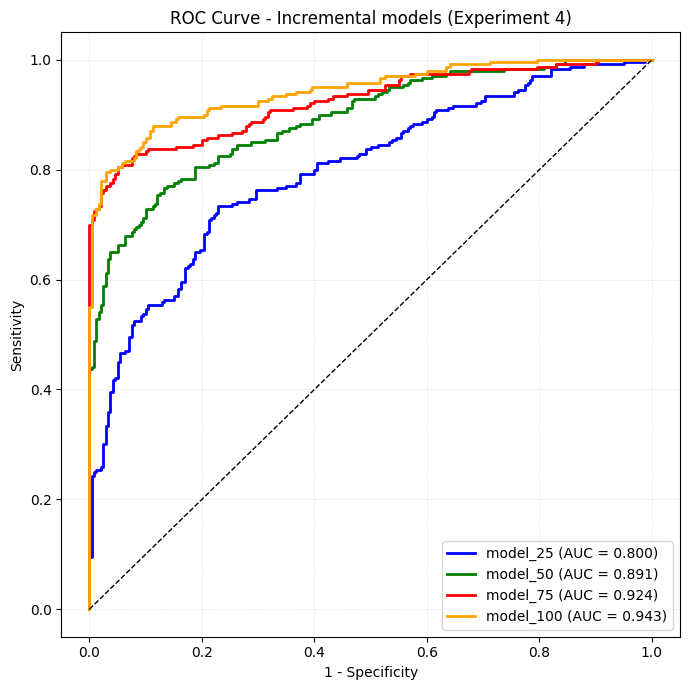

,Evaluation_name,cut_off_threshold_point,tn,fp,fn,tp,sensitivity,specificity,PPV,NPV,F1_score,accuracy,ROC_AUC,CI_90_lower,CI_90_upper,CI_95_lower,CI_95_upper,CI_99_lower,CI_99_upper
0,model_25,0.7026,185,55,64,176,0.7333,0.7708,0.7619,0.7430,0.7473,0.7521,0.8000,0.7668,0.8333,0.7604,0.8396,0.7480,0.8521
1,model_50,0.6272,208,32,56,184,0.7667,0.8667,0.8519,0.7879,0.8070,0.8167,0.8906,0.8655,0.9156,0.8607,0.9204,0.8513,0.9298
2,model_75,0.8094,228,12,47,193,0.8042,0.9500,0.9415,0.8291,0.8674,0.8771,0.9243,0.9035,0.9452,0.8995,0.9492,0.8917,0.9570
3,model_100,0.8328,233,7,49,191,0.7958,0.9708,0.9646,0.8262,0.8721,0.8833,0.9426,0.9245,0.9608,0.9210,0.9643,0.9142,0.9711


In [14]:
# Base path to save evaluation outputs for Experiment 4
base_save_path = 'big_volume/Tesis_definitivo/Evaluation/EXP4/'
os.makedirs(base_save_path, exist_ok=True)

# Models must be loaded beforehand (model_25, model_50, model_75, model_100)
models_dict = {
    "model_25": model_25,
    "model_50": model_50,
    "model_75": model_75,
    "model_100": model_100
}

# Keep the same colors as in the original code
model_colors = {
    "model_25": "blue",
    "model_50": "green",
    "model_75": "red",
    "model_100": "orange"
}


def auc_confidence_interval(y_true, y_score):
    """
    Compute the AUC and its confidence intervals using the method of
    Hanley & McNeil for binormal ROC curves.

    Parameters
    ----------
    y_true : array-like
        Binary ground-truth labels (0/1).
    y_score : array-like
        Predicted probabilities or continuous scores.

    Returns
    -------
    auc : float
        Area under the ROC curve.
    ci : dict
        Dictionary with lower and upper bounds for 90%, 95% and 99% CIs.
    """
    auc = roc_auc_score(y_true, y_score)
    n1 = sum(y_true)
    n2 = len(y_true) - n1
    q1 = auc / (2 - auc)
    q2 = 2 * auc**2 / (1 + auc)
    se_auc = np.sqrt(
        (auc * (1 - auc) +
         (n1 - 1) * (q1 - auc**2) +
         (n2 - 1) * (q2 - auc**2)) / (n1 * n2)
    )

    z = {0.90: 1.6449, 0.95: 1.96, 0.99: 2.5758}
    ci = {}
    for level in z:
        delta = z[level] * se_auc
        ci[f'CI {int(level * 100)}% lower'] = max(0, auc - delta)
        ci[f'CI {int(level * 100)}% upper'] = min(1, auc + delta)
    return auc, ci


# Store ROC curves for later joint plotting
roc_curves = {}

# Collect metrics for summary table
metrics_summary = []

# === Evaluation for each model ===
for name, model in models_dict.items():
    print(f'\n=== Evaluation: {name} ===')

    # Directory for saving results (kept consistent with other experiments)
    save_dir = os.path.join(base_save_path, name)
    os.makedirs(save_dir, exist_ok=True)

    # Predictions (probabilities)
    y_prob = model.predict(X_all).ravel()

    # ROC curve and Youden threshold
    fpr, tpr, thresholds = roc_curve(y_all, y_prob)
    youden_index = np.argmax(tpr - fpr)
    best_threshold = thresholds[youden_index]

    # Binary predictions using the chosen threshold
    y_pred = (y_prob >= best_threshold).astype(int)

    # Confusion matrix and metrics
    tn, fp, fn, tp = confusion_matrix(y_all, y_pred).ravel()
    sensitivity = recall_score(y_all, y_pred)
    specificity = tn / (tn + fp) if (tn + fp) else 0
    ppv = precision_score(y_all, y_pred, zero_division=0)
    npv = tn / (tn + fn) if (tn + fn) else 0
    f1 = f1_score(y_all, y_pred, zero_division=0)
    acc = accuracy_score(y_all, y_pred)
    auc, ci_dict = auc_confidence_interval(y_all, y_prob)

    print(f'Confusion matrix:\n[[{tn} {fp}]\n [{fn} {tp}]]\n')
    print(f'cut_off_threshold_point: {round(best_threshold, 4)}')
    print(f'Sensitivity: {round(sensitivity, 4)}')
    print(f'Specificity: {round(specificity, 4)}')
    print(f'PPV: {round(ppv, 4)}')
    print(f'NPV: {round(npv, 4)}')
    print(f'F1 score: {round(f1, 4)}')
    print(f'Accuracy: {round(acc, 4)}')
    print(f'ROC AUC: {round(auc, 4)}')
    print(f"CI 90%: [{round(ci_dict['CI 90% lower'], 4)} – {round(ci_dict['CI 90% upper'], 4)}]")
    print(f"CI 95%: [{round(ci_dict['CI 95% lower'], 4)} – {round(ci_dict['CI 95% upper'], 4)}]")
    print(f"CI 99%: [{round(ci_dict['CI 99% lower'], 4)} – {round(ci_dict['CI 99% upper'], 4)}]")

    # Store ROC curve for later joint plot
    roc_curves[name] = (fpr, tpr, auc)

    # ROC curve (per-model)
    plt.figure()
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=model_colors[name])
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('1 - Specificity')
    plt.ylabel('Sensitivity')
    plt.title(f'ROC Curve - {name}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f'ROC_{name}.png'),
                bbox_inches='tight', dpi=300)
    plt.close()

    # Metrics DataFrame (for this model)
    df_metrics = pd.DataFrame({
        'Evaluation_name': [name],
        'cut_off_threshold_point': [round(best_threshold, 4)],
        'tn': [tn],
        'fp': [fp],
        'fn': [fn],
        'tp': [tp],
        'sensitivity': [round(sensitivity, 4)],
        'specificity': [round(specificity, 4)],
        'PPV': [round(ppv, 4)],
        'NPV': [round(npv, 4)],
        'F1 score': [round(f1, 4)],
        'accuracy': [round(acc, 4)],
        'ROC AUC': [round(auc, 4)],
        'CI 90% lower': [round(ci_dict['CI 90% lower'], 4)],
        'CI 90% upper': [round(ci_dict['CI 90% upper'], 4)],
        'CI 95% lower': [round(ci_dict['CI 95% lower'], 4)],
        'CI 95% upper': [round(ci_dict['CI 95% upper'], 4)],
        'CI 99% lower': [round(ci_dict['CI 99% lower'], 4)],
        'CI 99% upper': [round(ci_dict['CI 99% upper'], 4)],
        'y_true': [list(y_all)],
        'y_pred_prob': [list(y_prob)]
    })
    df_metrics.to_csv(os.path.join(save_dir, f'{name}_metrics.csv'),
                      index=False)

    # Add row to summary list
    metrics_summary.append({
        'Evaluation_name': name,
        'cut_off_threshold_point': round(best_threshold, 4),
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp,
        'sensitivity': round(sensitivity, 4),
        'specificity': round(specificity, 4),
        'PPV': round(ppv, 4),
        'NPV': round(npv, 4),
        'F1_score': round(f1, 4),
        'accuracy': round(acc, 4),
        'ROC_AUC': round(auc, 4),
        'CI_90_lower': round(ci_dict['CI 90% lower'], 4),
        'CI_90_upper': round(ci_dict['CI 90% upper'], 4),
        'CI_95_lower': round(ci_dict['CI 95% lower'], 4),
        'CI_95_upper': round(ci_dict['CI 95% upper'], 4),
        'CI_99_lower': round(ci_dict['CI 99% lower'], 4),
        'CI_99_upper': round(ci_dict['CI 99% upper'], 4),
    })


# === Joint ROC for all incremental models ===
plt.figure(figsize=(7, 7))

for name in models_dict.keys():
    fpr, tpr, auc_val = roc_curves[name]
    plt.plot(
        fpr, tpr,
        label=f'{name} (AUC = {auc_val:.3f})',
        color=model_colors[name],
        linewidth=2
    )

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.title('ROC Curve - Incremental models (Experiment 4)')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.3)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.savefig(os.path.join(base_save_path, 'ROC_all_models.png'),
            bbox_inches='tight', dpi=300)
plt.show()
plt.close()

# === Final summary table of all evaluations ===
metrics_df_summary = pd.DataFrame(metrics_summary)
metrics_df_summary.to_csv(os.path.join(base_save_path, 'ALL_MODELS_METRICS.csv'),
                          index=False)

metrics_df_summary


#### **5.2. Statistical comparison between models (DeLong for AUC, McNemar for paired errors)**

In [11]:
# Build a joint DataFrame with aligned cases

def build_joint_eval_df_exp4(y_true, pred_dict):
    """
    Build a joint evaluation DataFrame for incremental models (Exp4).

    Parameters
    ----------
    y_true : array-like
        Ground-truth labels.
    pred_dict : dict
        Mapping model_name -> predicted probabilities.

    Returns
    -------
    df_joint : pd.DataFrame
        DataFrame with columns:
        ['label', 'y_pred_prob_<model_name>', ...]
    """
    df_joint = pd.DataFrame({
        "label": np.asarray(y_true).ravel()
    })

    for model_name, y_prob in pred_dict.items():
        df_joint[f"y_pred_prob_{model_name}"] = np.asarray(y_prob).ravel()

    return df_joint


# Build prediction dictionary (ensure same order as y_all)
pred_dict_exp4 = {
    name: model.predict(X_all).ravel()
    for name, model in models_dict.items()
}

df_joint_exp4 = build_joint_eval_df_exp4(
    y_true=y_all,
    pred_dict=pred_dict_exp4
)

print(f"Aligned cases for Experiment 4: {df_joint_exp4.shape[0]}")


15/15 [==============================] - 4s 268ms/step
Aligned cases for Experiment 4: 480


In [15]:
# === DeLong test for paired ROC AUC comparison (Experiment 4) ===


def _compute_midrank(x):
    """Compute midranks for ties."""
    sorted_idx = np.argsort(x)
    sorted_x = x[sorted_idx]
    N = len(x)
    midranks = np.zeros(N, dtype=float)

    i = 0
    while i < N:
        j = i
        while j < N and sorted_x[j] == sorted_x[i]:
            j += 1
        midrank = 0.5 * (i + j - 1) + 1
        midranks[i:j] = midrank
        i = j

    out = np.empty(N, dtype=float)
    out[sorted_idx] = midranks
    return out


def _fast_delong(predictions, labels):
    """
    Fast DeLong implementation for AUC variance (paired).

    IMPORTANT:
    Samples are reordered so that positives come first.
    predictions: array of shape (n_models, n_samples)
    labels: binary labels (0/1)
    """
    labels = labels.astype(int)

    # Reorder so that positives are first, negatives are last
    order = np.argsort(-labels)  # 1s first, then 0s
    labels = labels[order]
    predictions = predictions[:, order]

    m = np.sum(labels == 1)
    n = np.sum(labels == 0)

    preds_pos = predictions[:, :m]
    preds_neg = predictions[:, m:]

    k = predictions.shape[0]
    tx = np.empty((k, m))
    ty = np.empty((k, n))
    tz = np.empty((k, m + n))

    for r in range(k):
        tx[r] = _compute_midrank(preds_pos[r])
        ty[r] = _compute_midrank(preds_neg[r])
        tz[r] = _compute_midrank(predictions[r])

    aucs = (tz[:, :m].sum(axis=1) - m * (m + 1) / 2) / (m * n)

    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m

    sx = np.cov(v01)
    sy = np.cov(v10)

    return aucs, sx / m + sy / n


def delong_roc_test(y_true, pred_model_1, pred_model_2):
    """
    Paired DeLong test for ROC AUC comparison.

    Returns
    -------
    dict with keys:
    - auc1, auc2
    - delta_auc
    - z_score
    - p_value
    """
    y_true = np.asarray(y_true)
    preds = np.vstack([np.asarray(pred_model_1), np.asarray(pred_model_2)])

    aucs, cov = _fast_delong(preds, y_true)
    auc1, auc2 = aucs
    delta_auc = auc1 - auc2

    var = cov[0, 0] + cov[1, 1] - 2 * cov[0, 1]
    z = delta_auc / np.sqrt(var)
    p_value = 2 * (1 - norm.cdf(abs(z)))

    return {
        "auc1": auc1,
        "auc2": auc2,
        "delta_auc": delta_auc,
        "z_score": z,
        "p_value": p_value,
    }

def run_pairwise_delong_exp4(df_joint, alpha=0.05):
    y_true = df_joint["label"].values

    model_names = [
        "model_25",
        "model_50",
        "model_75",
        "model_100",
    ]

    print("\n=== DeLong tests (paired AUC) — Experiment 4 ===")

    results = []

    for i in range(len(model_names)):
        for j in range(i + 1, len(model_names)):
            m1, m2 = model_names[i], model_names[j]

            y1 = df_joint[f"y_pred_prob_{m1}"].values
            y2 = df_joint[f"y_pred_prob_{m2}"].values

            res = delong_roc_test(
                y_true=y_true,
                pred_model_1=y1,
                pred_model_2=y2
            )

            print(f"\nComparison: {m1} vs {m2}")
            print(f"AUC {m1}: {res['auc1']:.4f}")
            print(f"AUC {m2}: {res['auc2']:.4f}")
            print(f"Delta AUC ({m1} - {m2}): {res['delta_auc']:.4f}")
            print(f"Z-score: {res['z_score']:.4f}")
            print(f"P-value (two-sided): {res['p_value']:.4e}")

            results.append((m1, m2, res["p_value"], res["delta_auc"]))

    print(
        "\nNote:\n"
        "- Pairwise DeLong tests compare incremental training sizes.\n"
        "- Consider Holm correction if strict family-wise error control is required."
    )

    return results


_ = run_pairwise_delong_exp4(df_joint_exp4)



=== DeLong tests (paired AUC) — Experiment 4 ===

Comparison: model_25 vs model_50
AUC model_25: 0.8000
AUC model_50: 0.8906
Delta AUC (model_25 - model_50): -0.0906
Z-score: -5.6711
P-value (two-sided): 1.4186e-08

Comparison: model_25 vs model_75
AUC model_25: 0.8000
AUC model_75: 0.9243
Delta AUC (model_25 - model_75): -0.1243
Z-score: -6.6825
P-value (two-sided): 2.3486e-11

Comparison: model_25 vs model_100
AUC model_25: 0.8000
AUC model_100: 0.9426
Delta AUC (model_25 - model_100): -0.1426
Z-score: -7.9504
P-value (two-sided): 1.7764e-15

Comparison: model_50 vs model_75
AUC model_50: 0.8906
AUC model_75: 0.9243
Delta AUC (model_50 - model_75): -0.0338
Z-score: -2.7723
P-value (two-sided): 5.5667e-03

Comparison: model_50 vs model_100
AUC model_50: 0.8906
AUC model_100: 0.9426
Delta AUC (model_50 - model_100): -0.0521
Z-score: -4.6088
P-value (two-sided): 4.0494e-06

Comparison: model_75 vs model_100
AUC model_75: 0.9243
AUC model_100: 0.9426
Delta AUC (model_75 - model_100): -0

In [16]:
# Automatic interpretation of DeLong test results

def interpret_delong_results_exp4(df_joint, alpha=0.05):
    y_true = df_joint["label"].values

    model_names = [
        "model_25",
        "model_50",
        "model_75",
        "model_100",
    ]

    print("\n=== Interpretation of DeLong tests — Experiment 4 ===")

    for i in range(len(model_names)):
        for j in range(i + 1, len(model_names)):
            m1, m2 = model_names[i], model_names[j]

            y1 = df_joint[f"y_pred_prob_{m1}"].values
            y2 = df_joint[f"y_pred_prob_{m2}"].values

            res = delong_roc_test(y_true, y1, y2)

            auc1, auc2 = res["auc1"], res["auc2"]
            delta, p = res["delta_auc"], res["p_value"]

            if p < alpha:
                better = m1 if delta > 0 else m2
                conclusion = (
                    f"{better} shows a statistically significant higher AUC"
                )
            else:
                conclusion = "no statistically significant difference in AUC is observed"

            print(
                f"- {m1} vs {m2}: "
                f"AUCs = {auc1:.3f} vs {auc2:.3f}, "
                f"ΔAUC = {delta:.3f}, p = {p:.3e} → {conclusion}."
            )


interpret_delong_results_exp4(df_joint_exp4)



=== Interpretation of DeLong tests — Experiment 4 ===
- model_25 vs model_50: AUCs = 0.800 vs 0.891, ΔAUC = -0.091, p = 1.419e-08 → model_50 shows a statistically significant higher AUC.
- model_25 vs model_75: AUCs = 0.800 vs 0.924, ΔAUC = -0.124, p = 2.349e-11 → model_75 shows a statistically significant higher AUC.
- model_25 vs model_100: AUCs = 0.800 vs 0.943, ΔAUC = -0.143, p = 1.776e-15 → model_100 shows a statistically significant higher AUC.
- model_50 vs model_75: AUCs = 0.891 vs 0.924, ΔAUC = -0.034, p = 5.567e-03 → model_75 shows a statistically significant higher AUC.
- model_50 vs model_100: AUCs = 0.891 vs 0.943, ΔAUC = -0.052, p = 4.049e-06 → model_100 shows a statistically significant higher AUC.
- model_75 vs model_100: AUCs = 0.924 vs 0.943, ΔAUC = -0.018, p = 1.875e-02 → model_100 shows a statistically significant higher AUC.


### **6. Models Explainability**

In [15]:
# Explainability: Grad-CAM heatmaps 

def generate_gradcam_heatmaps(
    model,
    X_images,
    last_conv_layer_name: str = "block5_conv4",
    classifier_layer_names: list[str] | None = None,
    model_type: int = 2,
    overlay_alpha: float = 0.4,
    invert_heatmap: bool = True,
):

    if classifier_layer_names is None:
        classifier_layer_names = ["global_max_pooling2d", "dense"]

    heatmap_overlays = []
    preds_all = []

    # --- 1. Build convolutional model (used for feature map extraction) ---
    if model_type == 2:
        base_model = model.get_layer("vgg19")
        conv_output = base_model.get_layer(last_conv_layer_name).output
        conv_model = tf.keras.Model(inputs=base_model.input, outputs=conv_output)
    else:
        conv_output = model.get_layer(last_conv_layer_name).output
        conv_model = tf.keras.Model(inputs=model.input, outputs=conv_output)

    # --- 2. Build classifier model (maps feature maps -> prediction) ---
    classifier_input = tf.keras.Input(shape=conv_model.output.shape[1:])
    x = classifier_input

    if model_type == 2:
        x = model.get_layer("global_max_pooling2d")(x)
        x = model.get_layer("dense")(x)
    else:
        for layer_name in classifier_layer_names:
            x = model.get_layer(layer_name)(x)

    classifier_model = tf.keras.Model(inputs=classifier_input, outputs=x)

    # --- 3. Grad-CAM per image ---
    for img in X_images:
        img_input = np.expand_dims(img, axis=0)
        original_image = (img * 255).astype("uint8")

        with tf.GradientTape() as tape:
            conv_output_vals = conv_model(img_input)
            tape.watch(conv_output_vals)
            preds = classifier_model(conv_output_vals)
            class_channel = preds[:, 0]

        preds_all.append(float(preds.numpy()[0][0]))

        grads = tape.gradient(class_channel, conv_output_vals)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

        conv_output_vals = conv_output_vals.numpy()[0]
        pooled_grads = pooled_grads.numpy()

        conv_output_vals *= pooled_grads  # broadcast over HxW

        heatmap = np.mean(conv_output_vals, axis=-1)
        heatmap = np.maximum(heatmap, 0)
        heatmap = heatmap / (np.max(heatmap) + 1e-10)

        if invert_heatmap:
            heatmap = 1.0 - heatmap

        heatmap = cv2.resize(heatmap, (original_image.shape[1], original_image.shape[0]))
        heatmap_uint8 = np.uint8(255 * heatmap)
        heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

        overlay = cv2.addWeighted(heatmap_color, overlay_alpha, original_image, 1.0, 0)
        heatmap_overlays.append(overlay)

    return heatmap_overlays, preds_all


In [16]:
# === Generate Grad-CAM heatmaps for all models ===

# Dictionaries to store results
heatmaps_dict = {}
y_pred_dict = {}

# Last convolutional layer and classifier layers
last_conv_layer_name = "block5_conv4"
classifier_layers = ["global_max_pooling2d", "dense"]

# Grad-CAM generation per model
for name, model in models_dict.items():
    print(f"Generating Grad-CAM heatmaps for {name}...")

    heatmaps, preds = generate_gradcam_heatmaps(
        model,
        X_all,
        last_conv_layer_name,
        classifier_layers
    )

    heatmaps_dict[name] = heatmaps
    y_pred_dict[name] = preds

print("Grad-CAM heatmaps generated for all models.")


Generating Grad-CAM heatmaps for model_25...
Generating Grad-CAM heatmaps for model_50...
Generating Grad-CAM heatmaps for model_75...
Generating Grad-CAM heatmaps for model_100...
Grad-CAM heatmaps generated for all models.


In [17]:
# === Function to plot Grad-CAM heatmaps by image (row-wise) ===

def plot_heatmaps_by_row(heatmaps_dict, y_true, y_pred_dict, model_names=None, n_examples=5):
    """
    Plot Grad-CAM heatmaps for each image, displaying one column per model.

    Parameters
    ----------
    heatmaps_dict : dict
        Dictionary mapping model name -> list of heatmap images (one per input image).
    y_true : array-like
        Ground-truth labels (0 or 1), one per image.
    y_pred_dict : dict
        Dictionary mapping model name -> list of predicted probabilities (float in [0, 1]).
    model_names : list of str, optional
        Ordered list of model names to display. If None, all keys in heatmaps_dict are used.
    n_examples : int, optional
        Number of images (rows) to plot. Default is 5.
    """
    import matplotlib.pyplot as plt

    model_names = model_names or list(heatmaps_dict.keys())
    n_models = len(model_names)
    n_images = min(len(y_true), n_examples)

    for i in range(n_images):
        fig, axs = plt.subplots(1, n_models, figsize=(n_models * 5, 5))
        fig.suptitle(f"X-ray {i}", fontsize=16)

        for j, model_name in enumerate(model_names):
            heatmap = heatmaps_dict[model_name][i]
            pred_prob = min(y_pred_dict[model_name][i], 0.999)
            true_label = y_true[i]
            pred_label = 1 if pred_prob >= 0.5 else 0
            status = "Correct" if pred_label == true_label else "Error"

            # Si n_models == 1, axs no es lista/array; lo dejamos robusto sin cambiar nada visual.
            ax = axs[j] if n_models > 1 else axs
            ax.imshow(heatmap)
            ax.axis("off")
            ax.set_title(
                f"{model_name}\n"
                f"Label: {true_label} - {status}\n"
                f"Pred: {pred_prob:.3f}",
                fontsize=10
            )

        plt.tight_layout()
        plt.subplots_adjust(top=0.82)
        plt.show()


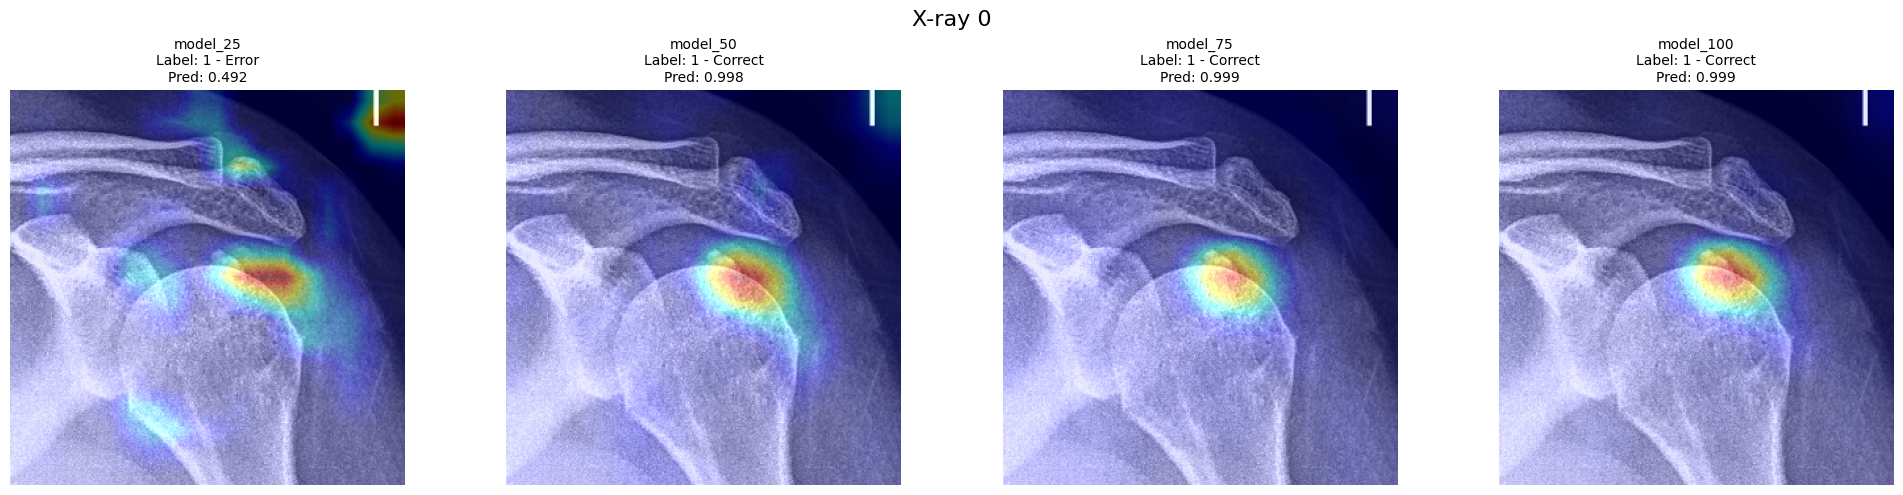

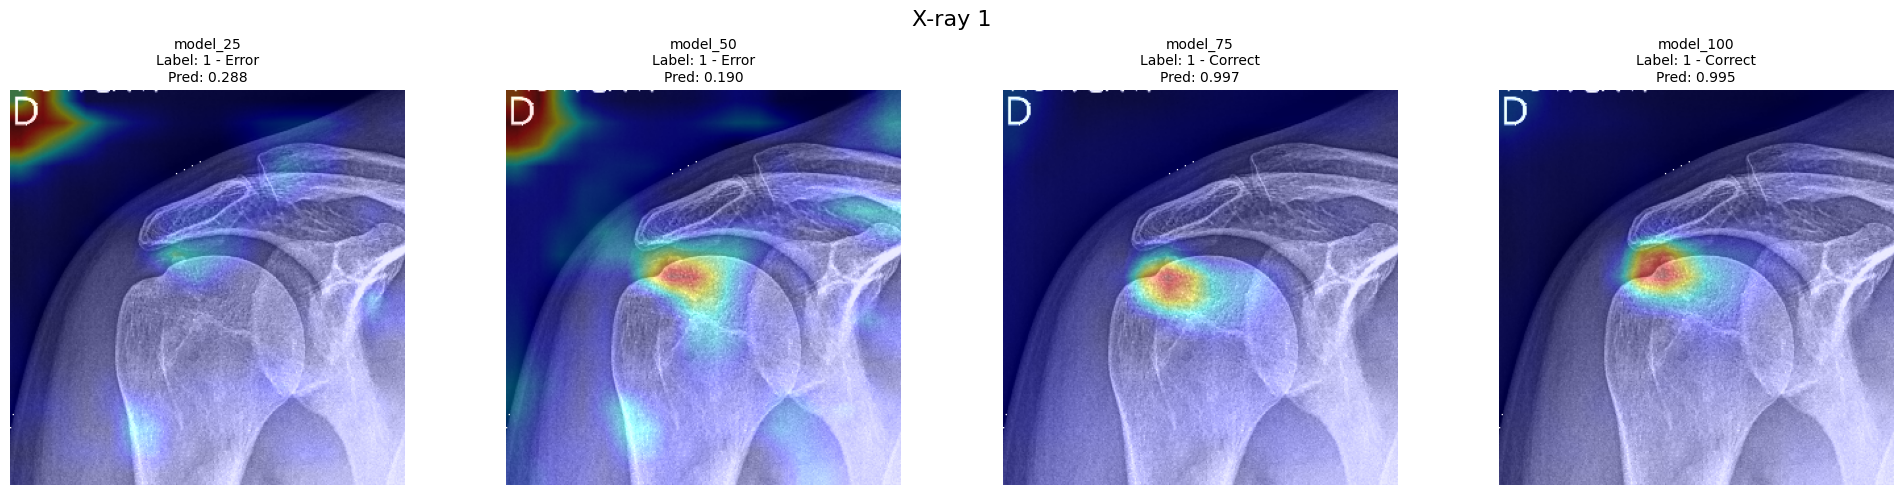

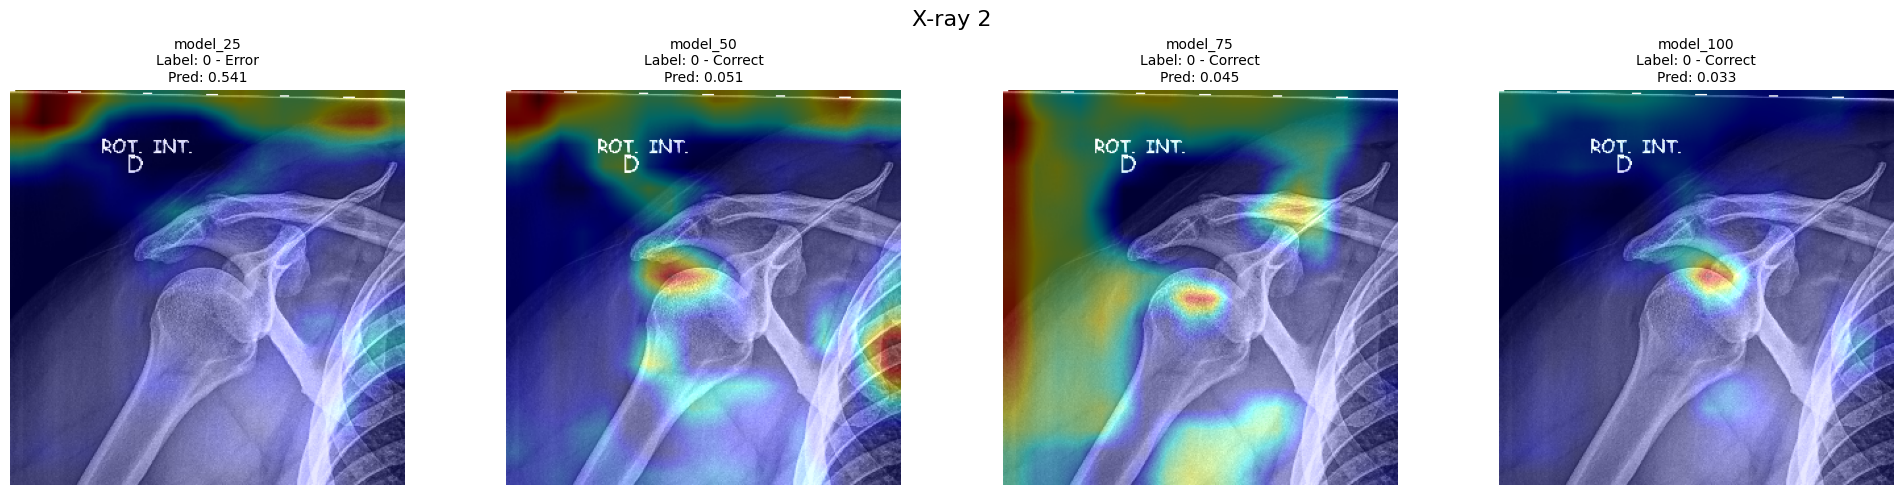

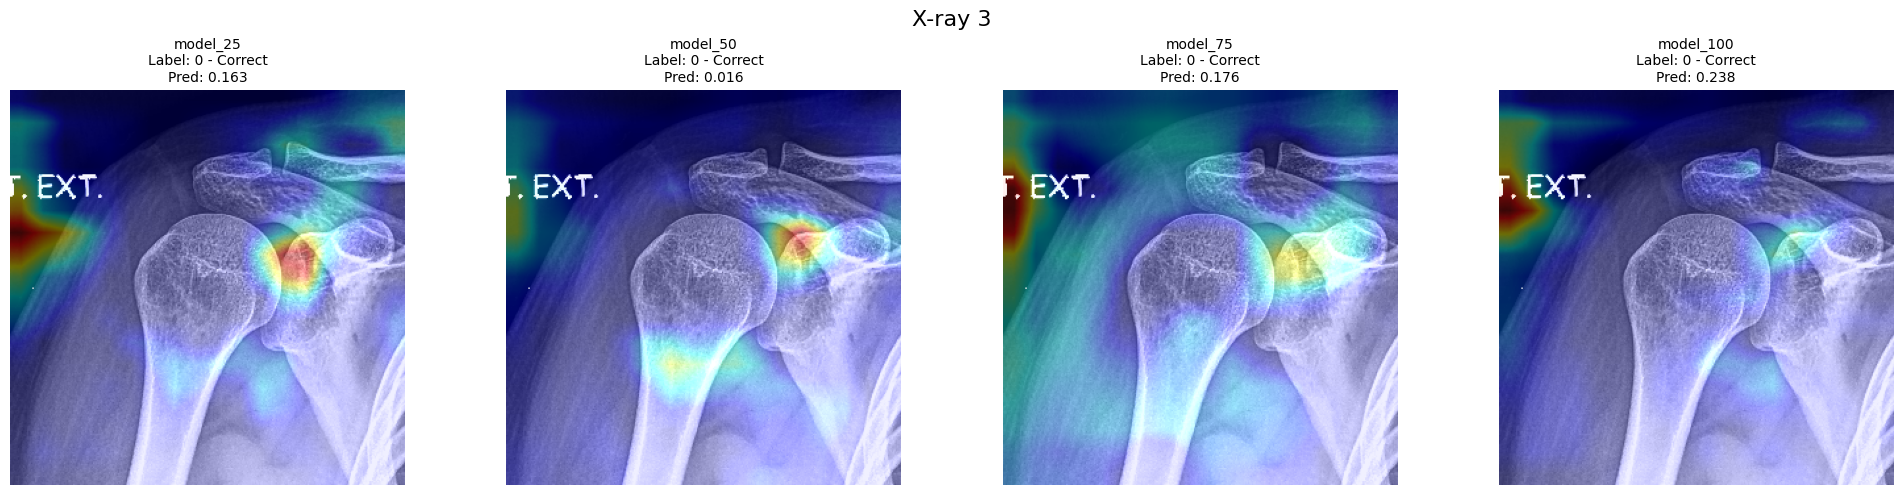

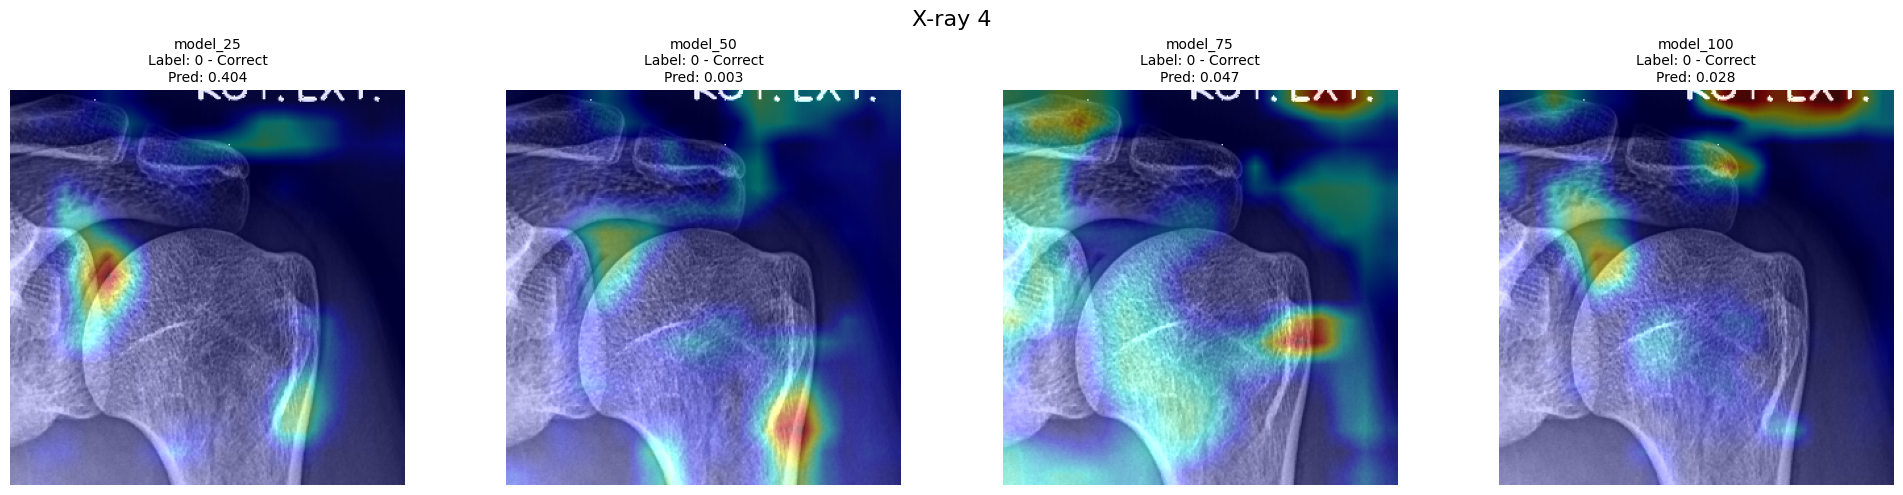

In [18]:
plot_heatmaps_by_row(
    heatmaps_dict=heatmaps_dict,
    y_true=y_all,
    y_pred_dict=y_pred_dict,
    model_names=[
        "model_25",
        "model_50",
        "model_75",
        "model_100",
    ],
)


### **7. Summary and Conclusions**

The results of Experiment 4 clearly support the initial hypothesis that training data volume plays a decisive role in the diagnostic performance of DL models. As the proportion of training data increases from 25% to 100%, all evaluated metrics show a consistent and meaningful improvement, reflecting a progressively enhanced ability of the models to correctly classify both positive and negative cases.

Quantitatively, the comparison across models reveals a steady increase in sensitivity, specificity, precision and F1-score, accompanied by a marked improvement in AUC, which rises from approximately 0.80 in the 25% model to around 0.94 in the model trained on the full dataset. The largest performance gains occur between the 25% and 75% training regimes, while the improvement from 75% to 100% is more moderate, suggesting a partial stabilization of the learning curve as the model approaches saturation.

Qualitative analysis using Grad-CAM heatmaps further reinforces these findings. Models trained with limited data exhibit more diffuse and anatomically inconsistent activations, whereas those trained on larger datasets show more focused attention on clinically plausible regions corresponding to calcifications. Together, these results emphasize that larger and more representative datasets not only improve quantitative performance, but also enhance model interpretability and reliability, underscoring data availability as a cornerstone for the development and clinical translation of AI-based tools in medical imaging.
